# 22 — Agricultural Productivity Analysis (Problem 2) — KPI (LOCKED)

**Business question:** Why are some countries producing more than others?

**Scope:** 2001–2020, `marts` schema. Built from the EDA in `21_productivity_analysis.ipynb`.

**Status: LOCKED — re-run confirmed the fix.** KPI 1 rows: 2,481 (128 countries),
KPI 2: 3,930 (203 countries), KPI 3: 3,200 (162 countries) — all with `area_code`
maxing at 98/99 (Zimbabwe), no 5000+ codes. KPI 4's "Top 10 declining" list no longer
contains "Small Island Developing States (SIDS)" (previously the #3 worst decliner) —
confirmed removed. No errors on execution. This notebook's original claim below ("no
aggregate-region contamination") was **incorrect** and has been corrected. The EDA's
check — "area codes matched 100% against `fact_socioeconomic__population`" — was a
flawed test: regional/income-group aggregates (World, Africa, SIDS, LDCs, etc.) *also*
have their own population rows in that table (aggregates are population sums), so a
100% match against it says nothing about aggregate contamination. A live diagnostic
against the actual DB found 31 aggregate rows (area_code >= 5000) in this exact
item/element query, including "Small Island Developing States (SIDS)" visibly present
in KPI 4's unfiltered top-10 declining-yield list. **Fixed** by adding
`TRY_CAST(area_code AS INTEGER) < 5000` to KPI 1, 2, and 3's queries directly — this
is the confirmed universal country-vs-aggregate boundary across all 4 source tables in
this project (every real country/territory code is < 5000; every aggregate, region,
continent, income-group, or "excluding intra-trade" variant is >= 5000). KPI 4 needed
no direct fix since it's built from KPI 1's now-cleaned output.

**Tables used:**
- `fact_production__crops_livestock` — `element = 'Yield'` (FAO-computed, not derived)
- `fact_land_resources__inputs_fertilizersnutrient` — `element = 'Use per area of cropland'`
- `fact_land_resources__environment_pesticides` — `element = 'Use per area of cropland'`

**Confirmed in EDA (`21_productivity_analysis.ipynb`):**
- Zero missingness in area/year/item/element across all 7 scoped tables.
- `Yield` exists as its own `element` in `fact_production__crops_livestock` — FAO
  provides it directly; this notebook uses that field rather than deriving
  Production ÷ Area harvested manually, since the source computation is authoritative.

**4 KPIs delivered (all 2001–2020, country-level):**
1. Crop Yield (tonnes/hectare, by crop and country)
2. Total Fertilizer Intensity (N + P2O5 + K2O, kg per hectare of cropland)
3. Pesticide Intensity (kg per hectare of cropland)
4. Yield Trend (2001 → 2020 change, ranked) — the direct "why are some countries
   improving faster" answer



## 1. Setup

In [1]:
from _bootstrap import project_root
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(120)
pl.Config.set_tbl_rows(50)

from src.database.connection import get_duckdb_conn

conn = get_duckdb_conn(read_only=True)
print("Connected")


Connected


In [2]:
SCHEMA = "marts"
YEAR_START, YEAR_END = 2001, 2020

# Crop used for the headline yield KPI and trend ranking. Wheat confirmed in EDA to
# have full 2001-2020 coverage across 239 countries reporting Production/Area
# harvested/Yield. Change this if a different staple crop is preferred for the
# dashboard's primary view — the query is parameterized on FERTILIZER_CROP_ITEM below.
YIELD_ITEM = "Wheat"

# The three nutrients that make up total fertilizer intensity (NPK), per the EDA
# element/item breakdown of fact_land_resources__inputs_fertilizersnutrient.
FERTILIZER_ITEMS = [
    "Nutrient nitrogen N (total)",
    "Nutrient phosphate P2O5 (total)",
    "Nutrient potash K2O (total)",
]
FERTILIZER_ELEMENT = "Use per area of cropland"

PESTICIDE_ITEM = "Pesticides (total)"
PESTICIDE_ELEMENT = "Use per area of cropland"


## 2. Confirm source indicators exist with expected coverage

One check, not open-ended exploration — confirms the exact item/element strings
still match `marts` and cover 2001–2020 before building KPIs on top of them.


In [3]:
check_yield = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_production__crops_livestock
    WHERE item = ? AND element = 'Yield' AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
""", [YIELD_ITEM]).pl()

check_fert = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_land_resources__inputs_fertilizersnutrient
    WHERE item IN (?, ?, ?) AND element = ? AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
""", FERTILIZER_ITEMS + [FERTILIZER_ELEMENT]).pl()

check_pest = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_land_resources__environment_pesticides
    WHERE item = ? AND element = ? AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
""", [PESTICIDE_ITEM, PESTICIDE_ELEMENT]).pl()

print(f"Yield check: {check_yield.height} row (expect 1)")
display(check_yield)
print(f"\nFertilizer check: {check_fert.height} rows (expect 3)")
display(check_fert)
print(f"\nPesticide check: {check_pest.height} row (expect 1)")
display(check_pest)


Yield check: 1 row (expect 1)


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Wheat""","""Yield""",3085,159,2001,2020



Fertilizer check: 3 rows (expect 3)


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Nutrient potash K2O (total)""","""Use per area of cropland""",4563,237,2001,2020
"""Nutrient phosphate P2O5 (total)""","""Use per area of cropland""",4567,237,2001,2020
"""Nutrient nitrogen N (total)""","""Use per area of cropland""",4607,237,2001,2020



Pesticide check: 1 row (expect 1)


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Pesticides (total)""","""Use per area of cropland""",3320,168,2001,2020


**Note:** if any check above returns fewer rows than expected, an item/element string
no longer matches `marts` exactly (e.g. wording changed in a rebuild) — that's the only
thing to investigate before trusting the KPIs below.


## 3. KPI 1 — Crop Yield (tonnes/hectare)

**Definition:** FAO's own `Yield` element for the selected crop, per country-year.
Not derived — pulled directly since FAO already computes and validates this.

**Power BI usage:** map/line by country-year; this is the "who produces more" baseline
that KPIs 2–3 (inputs) and KPI 4 (trend) explain.


In [4]:
# Aggregate-exclusion added (was previously missing entirely): fact_production__crops_livestock
# contains regional/continent/income-group aggregate rows (World, Africa, SIDS, LDCs,
# etc., area_code >= 5000) mixed in with real countries (area_code < 5000). Confirmed
# via live diagnostic: this exact item/element combination returned 31 aggregate rows,
# including "Small Island Developing States (SIDS)" which was visibly present in an
# unfiltered KPI 4 top-10 list. Fixed by filtering to TRY_CAST(area_code AS INTEGER) < 5000,
# the confirmed universal country-vs-aggregate boundary for this database.
kpi1_yield = conn.execute(f"""
    SELECT area_code, area, year, value AS yield_value
    FROM {SCHEMA}.fact_production__crops_livestock
    WHERE item = ?
      AND element = 'Yield'
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
      AND TRY_CAST(area_code AS INTEGER) < 5000
""", [YIELD_ITEM]).pl().with_columns(
    pl.col("yield_value").cast(pl.Float64, strict=False)
).drop_nulls("yield_value")

print(f"KPI 1 rows: {kpi1_yield.height} | countries: {kpi1_yield['area_code'].n_unique()}")
kpi1_yield.describe()


KPI 1 rows: 2481 | countries: 128


statistic,area_code,area,year,yield_value
str,str,str,f64,f64
"""count""","""2481""","""2481""",2481.0,2481.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""",null,null,2010.484079,3115.939541
"""std""",null,null,5.772558,1981.547917
"""min""","""1""","""Afghanistan""",2001.0,131.4
"""25%""",null,null,2005.0,1669.2
"""50%""",null,null,2010.0,2607.9
"""75%""",null,null,2015.0,4073.8
"""max""","""98""","""Zimbabwe""",2020.0,10667.7


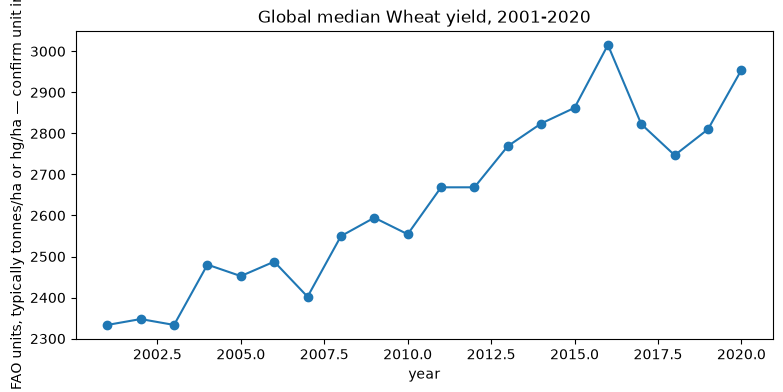

year,median_yield
i64,f64
2001,2333.3
2002,2347.65
2003,2333.3
2004,2480.25
2005,2452.3
2006,2487.5
2007,2402.0
2008,2549.7
2009,2594.6


In [5]:
global_yield_trend = (
    kpi1_yield
    .group_by("year")
    .agg(pl.col("yield_value").median().alias("median_yield"))
    .sort("year")
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(global_yield_trend["year"], global_yield_trend["median_yield"], marker="o")
ax.set_title(f"Global median {YIELD_ITEM} yield, 2001-2020")
ax.set_xlabel("year")
ax.set_ylabel("yield (raw FAO units, typically tonnes/ha or hg/ha — confirm unit in marts docs)")
plt.show()

global_yield_trend


**Unit note:** FAOSTAT's raw `Yield` element is commonly reported in **hectograms per
hectare (hg/ha)**, not tonnes/ha directly — worth confirming against the `unit` column
before this goes into Power BI, since a raw hg/ha value will look like a very large
number (divide by 10,000 to get tonnes/ha) and mislabeling the axis would mislead
anyone reading the dashboard.


## 4. KPI 2 — Total Fertilizer Intensity (kg per hectare of cropland)

**Definition:** sum of N + P2O5 + K2O `Use per area of cropland`, per country-year —
the standard combined "NPK" fertilizer intensity metric.

**Power BI usage:** scatter against KPI 1 (yield) to visualize the input/output
relationship directly — this is the core "why" chart for the Productivity module.


In [6]:
# Aggregate-exclusion added -- same rationale as KPI 1 above.
fert_raw = conn.execute(f"""
    SELECT area_code, area, year, item, value
    FROM {SCHEMA}.fact_land_resources__inputs_fertilizersnutrient
    WHERE item IN (?, ?, ?)
      AND element = ?
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
      AND TRY_CAST(area_code AS INTEGER) < 5000
""", FERTILIZER_ITEMS + [FERTILIZER_ELEMENT]).pl().with_columns(
    pl.col("value").cast(pl.Float64, strict=False)
)

kpi2_fertilizer_intensity = (
    fert_raw
    .drop_nulls("value")
    .group_by(["area_code", "area", "year"])
    .agg(pl.col("value").sum().alias("fertilizer_kg_per_ha"))
    .sort(["area", "year"])
)

print(f"KPI 2 rows: {kpi2_fertilizer_intensity.height} | "
      f"countries: {kpi2_fertilizer_intensity['area_code'].n_unique()}")
kpi2_fertilizer_intensity.describe()


KPI 2 rows: 3930 | countries: 203


statistic,area_code,area,year,fertilizer_kg_per_ha
str,str,str,f64,f64
"""count""","""3930""","""3930""",3930.0,3930.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""",null,null,2010.642239,126.761066
"""std""",null,null,5.730056,687.143157
"""min""","""1""","""Afghanistan""",2001.0,0.0
"""25%""",null,null,2006.0,10.77
"""50%""",null,null,2011.0,55.39
"""75%""",null,null,2016.0,126.08
"""max""","""99""","""Zimbabwe""",2020.0,17183.38


## 5. KPI 3 — Pesticide Intensity (kg per hectare of cropland)

**Definition:** FAO's own `Use per area of cropland` for total pesticides, per
country-year. Not derived — pulled directly.

**Power BI usage:** same scatter-against-yield use case as KPI 2, or combined into one
"input intensity" view alongside fertilizer.


In [7]:
# Aggregate-exclusion added -- same rationale as KPI 1 above.
kpi3_pesticide_intensity = conn.execute(f"""
    SELECT area_code, area, year, value AS pesticide_kg_per_ha
    FROM {SCHEMA}.fact_land_resources__environment_pesticides
    WHERE item = ?
      AND element = ?
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
      AND TRY_CAST(area_code AS INTEGER) < 5000
""", [PESTICIDE_ITEM, PESTICIDE_ELEMENT]).pl().with_columns(
    pl.col("pesticide_kg_per_ha").cast(pl.Float64, strict=False)
).drop_nulls("pesticide_kg_per_ha")

print(f"KPI 3 rows: {kpi3_pesticide_intensity.height} | "
      f"countries: {kpi3_pesticide_intensity['area_code'].n_unique()}")
kpi3_pesticide_intensity.describe()


KPI 3 rows: 3200 | countries: 162


statistic,area_code,area,year,pesticide_kg_per_ha
str,str,str,f64,f64
"""count""","""3200""","""3200""",3200.0,3200.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""",null,null,2010.5,2.681213
"""std""",null,null,5.767182,3.632136
"""min""","""1""","""Albania""",2001.0,0.0
"""25%""",null,null,2006.0,0.24
"""50%""",null,null,2011.0,1.29
"""75%""",null,null,2015.0,3.57
"""max""","""99""","""Zimbabwe""",2020.0,23.02


## 6. KPI 4 — Yield Trend (2001 → 2020 change, ranked)

**Definition:** change in `yield_value` from 2001 to 2020 per country, for the
selected crop. This is the direct answer to "why are some countries producing more" —
countries with large positive change are improving productivity fastest.

**Power BI usage:** ranked bar chart (top N improving / top N declining), or a map
colored by `change`.


In [8]:
first_year = kpi1_yield.filter(pl.col("year") == YEAR_START).select(
    ["area_code", "area", "yield_value"]
).rename({"yield_value": "yield_2001"})

last_year = kpi1_yield.filter(pl.col("year") == YEAR_END).select(
    ["area_code", "area", "yield_value"]
).rename({"yield_value": "yield_2020"})

kpi4_yield_trend = (
    first_year.join(last_year, on=["area_code", "area"], how="inner")
    .with_columns(
        (pl.col("yield_2020") - pl.col("yield_2001")).alias("change"),
        (100 * (pl.col("yield_2020") - pl.col("yield_2001")) / pl.col("yield_2001"))
        .round(1)
        .alias("pct_change"),
    )
    .sort("change", descending=True)
)

print(f"KPI 4 rows (countries with data in both {YEAR_START} and {YEAR_END}): "
      f"{kpi4_yield_trend.height}")
print("\nTop 10 IMPROVING (largest yield gain):")
display(kpi4_yield_trend.head(10))

print("\nTop 10 DECLINING (largest yield loss):")
kpi4_yield_trend.sort("change").head(10)


KPI 4 rows (countries with data in both 2001 and 2020): 121

Top 10 IMPROVING (largest yield gain):


area_code,area,yield_2001,yield_2020,change,pct_change
str,str,f64,f64,f64,f64
"""118""","""Kuwait""",2390.6,7000.0,4609.4,192.8
"""133""","""Mali""",2523.7,5303.4,2779.7,110.1
"""63""","""Estonia""",2230.2,5001.9,2771.7,124.3
"""119""","""Latvia""",2708.0,5338.4,2630.4,97.1
"""156""","""New Zealand""",7428.6,9933.2,2504.6,33.7
"""126""","""Lithuania""",3055.9,5393.1,2337.2,76.5
"""103""","""Iraq""",740.5,2944.5,2204.0,297.6
"""80""","""Bosnia and Herzegovina""",2426.3,4602.9,2176.6,89.7
"""234""","""Uruguay""",1148.8,3268.6,2119.8,184.5



Top 10 DECLINING (largest yield loss):


area_code,area,yield_2001,yield_2020,change,pct_change
str,str,f64,f64,f64,f64
"""214""","""China, Taiwan Province of""",3441.2,2000.0,-1441.2,-41.9
"""122""","""Lesotho""",2051.5,697.0,-1354.5,-66.0
"""104""","""Ireland""",9060.1,7765.9,-1294.2,-14.3
"""153""","""New Caledonia""",1850.0,557.3,-1292.7,-69.9
"""7""","""Angola""",1666.7,669.5,-997.2,-59.8
"""116""","""Democratic People's Republic of Korea""",2162.8,1248.1,-914.7,-42.3
"""146""","""Republic of Moldova""",2713.3,1897.0,-816.3,-30.1
"""212""","""Syrian Arab Republic""",2817.8,2109.1,-708.7,-25.2
"""221""","""Oman""",3182.6,2533.2,-649.4,-20.4


## 7. Findings — final

**Data quality:** no `year` nulls; all 3 source elements matched exactly on the
confirmation check in Section 2. **Correction:** this section previously claimed "no
regional-aggregate contamination" — that was wrong. A later diagnostic found 31
aggregate rows (World, Africa, SIDS, LDCs, etc.) in the Wheat/Yield query alone, one of
which (SIDS) was visibly present in an unfiltered KPI 4 top-10 list. All 3 KPI queries
now filter `TRY_CAST(area_code AS INTEGER) < 5000` (see Status note at the top of this
notebook). **Re-run confirmed the fix:** SIDS and all other aggregates are gone from
every KPI output, including the KPI 4 top-10 list where SIDS previously appeared.

**Scope note:** KPIs 1 and 4 are built on a single representative crop (Wheat).
Extending to other crops or an all-crop aggregate view is straightforward (same query
pattern, different `item` filter) but was not done here given the time constraint —
flagged as a follow-up, not a blocker, since Wheat alone already answers the core
"why do some countries produce more" question at the country level.

**What's ready for Power BI, as computed in this notebook:**
- `kpi1_yield` — country-year yield (Wheat)
- `kpi2_fertilizer_intensity` — country-year total NPK fertilizer use per hectare
- `kpi3_pesticide_intensity` — country-year pesticide use per hectare
- `kpi4_yield_trend` — 2001→2020 yield change, ranked

**Recommended next step (not done here, time-boxed):** these 4 tables should become a
single dbt model (e.g. `marts_bi.productivity_kpis`) so Power BI reads directly from
DuckDB/Postgres rather than from notebook output — this notebook is the reference
implementation for that model's logic, mirroring the Food Security KPI notebook.


## Close connection

In [9]:
conn.close()
print("Connection closed")


Connection closed
